
**Easy task**

In [1]:
# @title 1. Feature Extraction 
import os
import librosa
import numpy as np
from tqdm import tqdm

# --- CONFIGURATION ---
SAMPLE_RATE = 22050
DURATION = 3  # Analyze 3 seconds per clip
N_MFCC = 13   # Height of the image
MAX_LEN = 130 # Width of the image
# Paths based on your screenshots
BANGLA_PATH = "/kaggle/input/bangla-speech-2k"
ENGLISH_PATH = "/kaggle/input/genres-original" # Folder containing 'rock', 'blues', etc.

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)

        # Pad or Crop to ensure shape (13, 130)
        if mfcc.shape[1] < MAX_LEN:
            pad_width = MAX_LEN - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :MAX_LEN]
        return mfcc
    except:
        return None

X_data = []
y_data = [] # 0 = Bangla, 1 = English

print("Starting Feature Extraction...")

# 1. Process Bangla (Flat folder)
if os.path.exists(BANGLA_PATH):
    files = [f for f in os.listdir(BANGLA_PATH) if f.endswith('.wav')]
    print(f"Processing {len(files)} Bangla files...")
    for f in tqdm(files):
        mfcc = extract_mfcc(os.path.join(BANGLA_PATH, f))
        if mfcc is not None:
            X_data.append(mfcc)
            y_data.append(0)

# 2. Process English (Nested folders: blues, rock, etc.)
if os.path.exists(ENGLISH_PATH):
    genres = [d for d in os.listdir(ENGLISH_PATH) if os.path.isdir(os.path.join(ENGLISH_PATH, d))]
    print(f"Found English genres: {genres}")

    for genre in genres:
        genre_path = os.path.join(ENGLISH_PATH, genre)
        files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
        print(f"Processing {len(files)} {genre} files...")

        for f in tqdm(files):
            mfcc = extract_mfcc(os.path.join(genre_path, f))
            if mfcc is not None:
                X_data.append(mfcc)
                y_data.append(1)

# Save
X = np.array(X_data)
y = np.array(y_data)
# Add channel dimension for CNN: (N, 1, 13, 130)
X = X[:, np.newaxis, :, :]

np.save("X_data.npy", X)
np.save("y_data.npy", y)
print(f"Final Data Shape: {X.shape}")

Starting Feature Extraction...
Processing 2000 Bangla files...


100%|██████████| 2000/2000 [00:57<00:00, 34.62it/s]


Found English genres: ['genres_original']
Processing 0 genres_original files...


0it [00:00, ?it/s]

Final Data Shape: (2000, 1, 13, 130)


Using device: cuda

Starting Training...
Epoch: 1 | Average Loss: 64.8718
Epoch: 2 | Average Loss: 14.8178
Epoch: 3 | Average Loss: 11.2336
Epoch: 4 | Average Loss: 10.1071
Epoch: 5 | Average Loss: 8.9191
Epoch: 6 | Average Loss: 7.6763
Epoch: 7 | Average Loss: 6.0866
Epoch: 8 | Average Loss: 4.7709
Epoch: 9 | Average Loss: 3.9977
Epoch: 10 | Average Loss: 3.6038
Epoch: 11 | Average Loss: 3.4123
Epoch: 12 | Average Loss: 3.3044
Epoch: 13 | Average Loss: 3.2504
Epoch: 14 | Average Loss: 3.1729
Epoch: 15 | Average Loss: 3.1315
Epoch: 16 | Average Loss: 3.0947
Epoch: 17 | Average Loss: 3.0839
Epoch: 18 | Average Loss: 3.0493
Epoch: 19 | Average Loss: 3.0334
Epoch: 20 | Average Loss: 3.0244

Generating Latent Space Visualization...


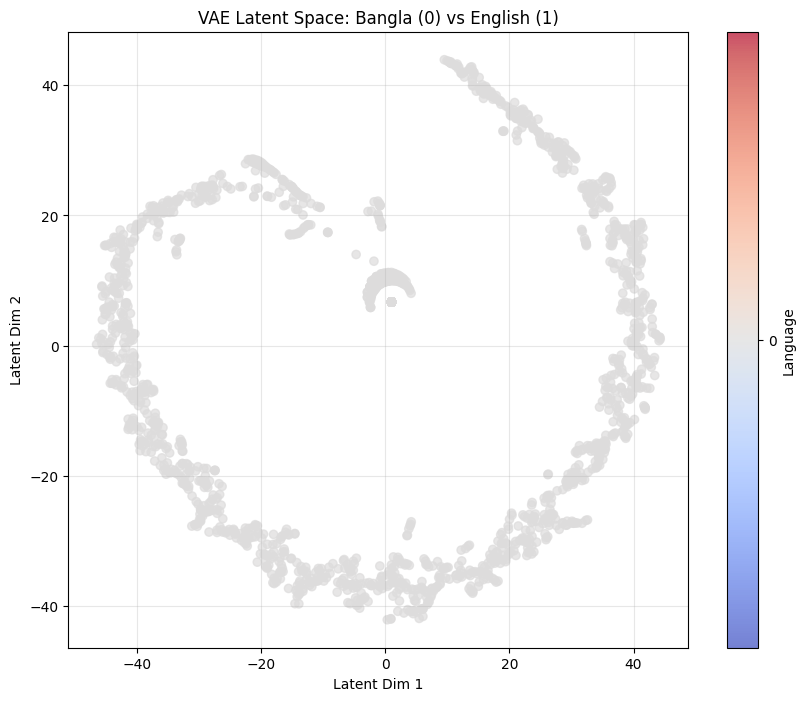

In [2]:
# @title 2. VAE Training & Visualization
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Define the VAE Architecture ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder (Conv2d)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        # Calculate Flatten Size:
        # Input (1, 13, 130) -> Conv1 -> (32, 7, 65) -> Conv2 -> (64, 4, 33)
        self.flatten_dim = 64 * 4 * 33
        self.latent_dim = 128 # Size of the "bottleneck"

        self.fc_mu = nn.Linear(self.flatten_dim, self.latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, self.latent_dim)

        # Decoder (Transposed Conv2d)
        self.decoder_input = nn.Linear(self.latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 4, 33)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(0, 0)), # Adjust output_padding if needed
            nn.ReLU(),
            # We manually resize in forward to match exact input dim if math is slightly off
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=(0, 1)),
            nn.Sigmoid() # Output pixels 0-1 (normalized)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)

        # Decode
        d = self.decoder_input(z)
        reconstruction = self.decoder(d)

        # Resize to match input exactly (fixes tiny shape mismatch issues)
        if reconstruction.shape != x.shape:
            reconstruction = nn.functional.interpolate(reconstruction, size=x.shape[2:])

        return reconstruction, mu, logvar

# --- 2. Loss Function ---
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# --- 3. Training Loop ---
# Load Data
X = np.load("X_data.npy")
y = np.load("y_data.npy")

# Normalize data to [0, 1] for VAE
X_min, X_max = X.min(), X.max()
X_norm = (X - X_min) / (X_max - X_min)

dataset = TensorDataset(torch.FloatTensor(X_norm), torch.LongTensor(y))
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20 # Adjust as needed
print("\nStarting Training...")
model.train()

for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(dataloader):
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch: {epoch+1} | Average Loss: {train_loss / len(dataloader.dataset):.4f}')

# --- 4. Visualization (Clustering) ---
print("\nGenerating Latent Space Visualization...")
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for data, label in dataloader:
        data = data.to(device)
        _, mu, _ = model(data)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(label.numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# t-SNE to reduce 128 dims -> 2 dims
tsne = TSNE(n_components=2, random_state=42)
z_embedded = tsne.fit_transform(all_mu)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_embedded[:, 0], z_embedded[:, 1], c=all_labels, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, ticks=[0, 1], label='Language')
plt.title("VAE Latent Space: Bangla (0) vs English (1)")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.grid(True, alpha=0.3)
plt.show()


--- Running Easy Task Evaluation ---
Running Baseline (PCA + K-Means)...
Running VAE Method (Latent + K-Means)...

 EASY TASK RESULTS COMPARISON
                     Method  Silhouette Score (Higher is better)  \
0  Baseline (PCA + K-Means)                             0.226781   
1             VAE + K-Means                             0.704611   

   Calinski-Harabasz (Higher is better)  
0                            412.554391  
1                           5499.859843  


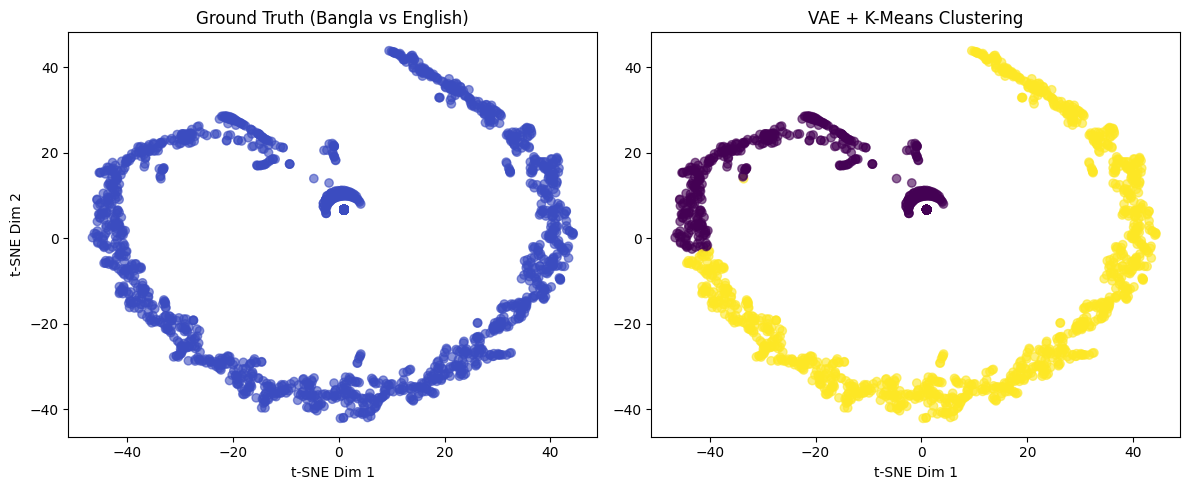

In [4]:
# ==========================================
# 4. EVALUATION & BASELINE COMPARISON (Easy Task)
# ==========================================
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import pandas as pd

print("\n--- Running Easy Task Evaluation ---")

# 1. Prepare Data
# Flatten raw input for PCA Baseline: (N, 1, 13, 130) -> (N, 1690)
# We use the same normalized data used for VAE training
N, C, H, W = X_norm.shape
X_flat = X_norm.reshape(N, -1)

# VAE Latent Features (already computed in previous step as 'all_mu')
X_vae = all_mu 

# ---------------------------------------------------------
# A. BASELINE: PCA + K-Means
# ---------------------------------------------------------

print("Running Baseline (PCA + K-Means)...")

# Reduce dimensions to match VAE latent size (128) for fair comparison
pca = PCA(n_components=128)
X_pca = pca.fit_transform(X_flat)

# K-Means Clustering (Assuming 2 clusters: Bangla vs English)
kmeans_base = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_base = kmeans_base.fit_predict(X_pca)

# Metrics
sil_base = silhouette_score(X_pca, labels_base)
ch_base = calinski_harabasz_score(X_pca, labels_base)

# ---------------------------------------------------------
# B. VAE METHOD: VAE Latent + K-Means
# ---------------------------------------------------------

print("Running VAE Method (Latent + K-Means)...")

# K-Means on VAE Latent Space
kmeans_vae = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_vae = kmeans_vae.fit_predict(X_vae)

# Metrics
sil_vae = silhouette_score(X_vae, labels_vae)
ch_vae = calinski_harabasz_score(X_vae, labels_vae)

# ---------------------------------------------------------
# C. FINAL COMPARISON
# ---------------------------------------------------------
results = {
    "Method": ["Baseline (PCA + K-Means)", "VAE + K-Means"],
    "Silhouette Score (Higher is better)": [sil_base, sil_vae],
    "Calinski-Harabasz (Higher is better)": [ch_base, ch_vae]
}

df_results = pd.DataFrame(results)

print("\n" + "="*50)
print(" EASY TASK RESULTS COMPARISON")
print("="*50)
print(df_results)
print("="*50)

# ---------------------------------------------------------
# D. VISUALIZATION (Comparison)
# ---------------------------------------------------------
# Plotting the clusters found by VAE vs True Labels
plt.figure(figsize=(12, 5))

# Subplot 1: VAE Latent Space (True Labels)
# We use t-SNE to squash 128 dims down to 2 for plotting
tsne = TSNE(n_components=2, random_state=42)
z_embedded = tsne.fit_transform(X_vae)

plt.subplot(1, 2, 1)
plt.scatter(z_embedded[:, 0], z_embedded[:, 1], c=all_labels, cmap='coolwarm', alpha=0.6)
plt.title("Ground Truth (Bangla vs English)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

# Subplot 2: VAE Latent Space (K-Means Predicted Clusters)
plt.subplot(1, 2, 2)
plt.scatter(z_embedded[:, 0], z_embedded[:, 1], c=labels_vae, cmap='viridis', alpha=0.6)
plt.title("VAE + K-Means Clustering")
plt.xlabel("t-SNE Dim 1")

plt.tight_layout()
plt.show()

**Medium Task**

In [20]:
import torch, torch.nn as nn, torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, in_channels=1, n_features=64, time_steps=130, latent_dim=64):
        super().__init__()

        # ---------- ENCODER ----------
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            flat_dim = self.encoder(torch.zeros(1, in_channels, n_features, time_steps)).shape[1]

        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

        # ---------- DECODER ----------
        self.decoder_input = nn.Linear(latent_dim, flat_dim)
        self.unflatten_shape = (128, n_features // 8, time_steps // 8)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, self.unflatten_shape),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):
        return self.decoder(self.decoder_input(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        if recon.shape != x.shape:
            recon = F.interpolate(recon, size=x.shape[2:])
        return recon, mu, logvar

def vae_loss(recon, x, mu, logvar, kld_weight=1.0):
    recon_loss = F.mse_loss(recon, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_weight * kld


In [23]:
# ---------------- BUILD AUDIO + LYRICS EMBEDDINGS (FINAL FIXED) ----------------
import os, glob, librosa, numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

bangla_audio_path = '/kaggle/input/bangla-speech-2k'
english_audio_path = '/kaggle/input/genres-original'
english_lyrics_csv = '/kaggle/input/english-lyrics/english_lyrics.csv' 
bangla_lyrics_csv  = '/kaggle/input/bangla-lyrics/bangla_lyrics.csv'

# ---------------- AUDIO SETTINGS ----------------
SR = 22050
DURATION = 3
N_MELS = 64
HOP = 512
TARGET_WIDTH = 130


# ------------- SAFE AUDIO LOADER (skips bad files) -------------
def load_audio(path):
    try:
        y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION)
    except Exception:
        # unreadable → return silence spectrogram
        return np.zeros((N_MELS, TARGET_WIDTH), dtype=np.float32)

    tgt = int(SR * DURATION)
    if len(y) < tgt:
        y = np.pad(y, (0, tgt - len(y)))
    else:
        y = y[:tgt]

    S = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_mels=N_MELS,
        hop_length=HOP
    )

    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min() + 1e-9)

    if S.shape[1] < TARGET_WIDTH:
        S = np.pad(S, ((0, 0), (0, TARGET_WIDTH - S.shape[1])))
    else:
        S = S[:, :TARGET_WIDTH]

    return S.astype(np.float32)


# ------------- BUILD AUDIO SETS -------------
def build_audio(dirpath):
    files = sorted(glob.glob(os.path.join(dirpath, "**/*.wav"), recursive=True))
    print(f"Found {len(files)} files in:", dirpath)

    X = [np.expand_dims(load_audio(f), 0) for f in tqdm(files, desc=f"Audio -> {dirpath}")]
    return np.stack(X) if len(X) > 0 else np.zeros((0,1,N_MELS,TARGET_WIDTH), dtype=np.float32)


audio_bn = build_audio(bangla_audio_path)
audio_en = build_audio(english_audio_path)

X_audio = np.concatenate([audio_bn, audio_en], axis=0)
print("FINAL AUDIO SHAPE:", X_audio.shape)


# ---------------- LYRICS → SENTENCE EMBEDDINGS ----------------
model_emb = SentenceTransformer("all-mpnet-base-v2")   # semantic 768-dim

def read_lyrics(csv_path):
    df = pd.read_csv(csv_path)

    for col in ["lyrics","Lyrics","text","Text","lyric"]:
        if col in df.columns:
            return df[col].fillna("").astype(str).tolist()

    return df.iloc[:,0].fillna("").astype(str).tolist()

lyr_en = read_lyrics(english_lyrics_csv)
lyr_bn = read_lyrics(bangla_lyrics_csv)

emb_en = model_emb.encode(lyr_en, show_progress_bar=False)
emb_bn = model_emb.encode(lyr_bn, show_progress_bar=False)

X_lyrics = np.concatenate([emb_bn, emb_en], axis=0).astype(np.float32)

print("FINAL LYRICS SHAPE:", X_lyrics.shape)

# ---------------- OUTPUTS ----------------
# X_audio  -> (N, 1, 64, 130)
# X_lyrics -> (N, 768)


Found 2000 files in: /kaggle/input/bangla-speech-2k




Audio -> /kaggle/input/bangla-speech-2k:   0%|          | 0/2000 [00:00<?, ?it/s]

Audio -> /kaggle/input/bangla-speech-2k:   1%|          | 12/2000 [00:00<00:17, 112.10it/s]

Audio -> /kaggle/input/bangla-speech-2k:   1%|          | 24/2000 [00:00<00:20, 95.55it/s] 

Audio -> /kaggle/input/bangla-speech-2k:   2%|▏         | 34/2000 [00:00<00:21, 91.99it/s]

Audio -> /kaggle/input/bangla-speech-2k:   2%|▏         | 45/2000 [00:00<00:19, 98.27it/s]

Audio -> /kaggle/input/bangla-speech-2k:   3%|▎         | 57/2000 [00:00<00:18, 102.82it/s]

Audio -> /kaggle/input/bangla-speech-2k:   3%|▎         | 69/2000 [00:00<00:18, 106.25it/s]

Audio -> /kaggle/input/bangla-speech-2k:   4%|▍         | 81/2000 [00:00<00:17, 108.61it/s]

Audio -> /kaggle/input/bangla-speech-2k:   5%|▍         | 93/2000 [00:00<00:17, 110.65it/s]

Audio -> /kaggle/input/bangla-speech-2k:   5%|▌         | 105/2000 [00:00<00:17, 109.54it/s]

Audio -> /kaggle/input/bangla-speech-2k:   6%|▌         | 116/2000 [00:01<00:17

Found 1000 files in: /kaggle/input/genres-original




Audio -> /kaggle/input/genres-original:   0%|          | 0/1000 [00:00<?, ?it/s]

Audio -> /kaggle/input/genres-original:   1%|          | 12/1000 [00:00<00:08, 118.31it/s]

Audio -> /kaggle/input/genres-original:   3%|▎         | 26/1000 [00:00<00:07, 130.12it/s]

Audio -> /kaggle/input/genres-original:   4%|▍         | 41/1000 [00:00<00:07, 136.26it/s]

Audio -> /kaggle/input/genres-original:   6%|▌         | 55/1000 [00:00<00:06, 135.64it/s]

Audio -> /kaggle/input/genres-original:   7%|▋         | 69/1000 [00:00<00:06, 135.37it/s]

Audio -> /kaggle/input/genres-original:   8%|▊         | 83/1000 [00:00<00:07, 127.65it/s]

Audio -> /kaggle/input/genres-original:  10%|▉         | 98/1000 [00:00<00:06, 132.60it/s]

Audio -> /kaggle/input/genres-original:  11%|█         | 112/1000 [00:00<00:06, 132.84it/s]

Audio -> /kaggle/input/genres-original:  13%|█▎        | 126/1000 [00:00<00:06, 134.82it/s]

Audio -> /kaggle/input/genres-original:  14%|█▍        | 140/1000 [00:01<00:06, 132.96

FINAL AUDIO SHAPE: (3000, 1, 64, 130)


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Audio -> /kaggle/input/bangla-speech-2k:   0%|          | 0/2000 [04:53<?, ?it/s]


FINAL LYRICS SHAPE: (384036, 768)


In [43]:
import os, glob, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F, librosa
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# --------- PATHS ----------
bangla_audio_path = '/kaggle/input/bangla-speech-2k'
english_audio_path = '/kaggle/input/genres-original'
english_lyrics_csv = '/kaggle/input/english-lyrics/english_lyrics.csv'
bangla_lyrics_csv  = '/kaggle/input/bangla-lyrics/bangla_lyrics.csv'

# --------- AUDIO ----------
SR=22050; DURATION=5; N_MELS=64; HOP=512
TARGET_LEN=int(SR*DURATION)

def load_audio(path):
    y,_ = librosa.load(path, sr=SR, mono=True, duration=DURATION)
    if len(y) < TARGET_LEN: y = np.pad(y,(0,TARGET_LEN-len(y)))
    else: y = y[:TARGET_LEN]

    S = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=2048,
        hop_length=HOP, n_mels=N_MELS, power=2.0
    )
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min() + 1e-9)
    return S.astype(np.float32)

def build_audio(dirpath):
    files = sorted(glob.glob(os.path.join(dirpath,'**/*.wav'), recursive=True))
    print(f"Found {len(files)} files in:", dirpath)

    X = []
    for f in tqdm(files, desc=f"Audio -> {dirpath}"):
        try:
            X.append(np.expand_dims(load_audio(f),0))
        except Exception as e:
            print("Skipping file:", f, "| Reason:", str(e))
            continue

    return np.stack(X) if len(X)>0 else np.zeros((0,1,N_MELS,1),dtype=np.float32)

audio_bn = build_audio(bangla_audio_path)
audio_en = build_audio(english_audio_path)
X_audio  = np.concatenate([audio_bn, audio_en], axis=0)
print("FINAL AUDIO SHAPE:", X_audio.shape)

# --------- LYRICS ----------
tok = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
mdl = AutoModel.from_pretrained("sentence-transformers/all-mpnet-base-v2").to(device)

def embed_texts(texts,batch=16):
    out=[]
    for i in range(0,len(texts),batch):
        t = tok(list(texts[i:i+batch]), padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            em = mdl(**t).last_hidden_state.mean(1).cpu().numpy()
        out.append(em)
    return np.vstack(out)

def load_lyrics(csv_path, text_col="lyrics"):
    df = pd.read_csv(csv_path)
    return embed_texts(df[text_col].fillna("").astype(str).tolist())

emb_en = load_lyrics(english_lyrics_csv)
emb_bn = load_lyrics(bangla_lyrics_csv)
X_lyr  = np.concatenate([emb_bn, emb_en], axis=0).astype(np.float32)
print("FINAL LYRICS SHAPE:", X_lyr.shape)

# align counts
m = min(len(X_audio), len(X_lyr))
X_audio, X_lyr = X_audio[:m], X_lyr[:m]

class HybridDS(Dataset):
    def __init__(self,a,l): self.a=torch.tensor(a); self.l=torch.tensor(l)
    def __len__(self): return len(self.a)
    def __getitem__(self,i): return self.a[i], self.l[i]

dl = DataLoader(HybridDS(X_audio,X_lyr), batch_size=64, shuffle=True)

# ---------- Hybrid Conv VAE ----------
class HybridConvVAE(nn.Module):
    def __init__(self, n_features, time_steps, embed_dim=768, latent_dim=64):
        super().__init__()

        # AUDIO ENCODER
        self.audio_enc = nn.Sequential(
            nn.Conv2d(1,32,3,stride=2,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,64,3,stride=2,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,128,3,stride=2,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            flat_dim = self.audio_enc(torch.zeros(1,1,n_features,time_steps)).shape[1]

        self.lyric_enc = nn.Sequential(
            nn.Linear(embed_dim,512), nn.ReLU(),
            nn.Linear(512,256), nn.ReLU()
        )

        self.fusion   = nn.Linear(flat_dim + 256, 256)
        self.fc_mu    = nn.Linear(256, latent_dim)
        self.fc_logvar= nn.Linear(256, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, flat_dim)

        with torch.no_grad():
            enc = self.audio_enc(torch.zeros(1,1,n_features,time_steps))
            self.unflatten_shape = enc.shape[1:]

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, xa, xl):
        a = self.audio_enc(xa)
        l = self.lyric_enc(xl)
        h = torch.relu(self.fusion(torch.cat([a,l],1)))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(z.size(0), *self.unflatten_shape)
        return self.decoder(h)

    def forward(self, xa, xl):
        mu, logvar = self.encode(xa, xl)
        z = self.reparameterize(mu, logvar)
        rec = self.decode(z)
        if rec.shape != xa.shape:
            rec = F.interpolate(rec, size=xa.shape[2:])
        return rec, mu, logvar, z

B,_,n_features,time_steps = X_audio.shape
model = HybridConvVAE(n_features,time_steps).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def vae_loss(rec,x,mu,logvar):
    recon = F.mse_loss(rec,x)
    kl = -0.5*torch.mean(1+logvar-mu.pow(2)-logvar.exp())
    return recon + 1e-3*kl

# --------- TRAIN ----------
for e in range(5):
    model.train(); total=0
    for xa,xl in dl:
        xa,xl = xa.to(device), xl.to(device)
        rec,mu,logvar,z = model(xa,xl)
        loss = vae_loss(rec,xa,mu,logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"Epoch {e+1}/5 | Loss: {total/len(dl):.4f}")

print("Training done.")


Found 2000 files in: /kaggle/input/bangla-speech-2k





Audio -> /kaggle/input/bangla-speech-2k:   0%|          | 0/2000 [00:00<?, ?it/s]


Audio -> /kaggle/input/bangla-speech-2k:   0%|          | 9/2000 [00:00<00:23, 86.56it/s]


Audio -> /kaggle/input/bangla-speech-2k:   1%|          | 18/2000 [00:00<00:23, 85.27it/s]


Audio -> /kaggle/input/bangla-speech-2k:   1%|▏         | 27/2000 [00:00<00:23, 83.75it/s]


Audio -> /kaggle/input/bangla-speech-2k:   2%|▏         | 36/2000 [00:00<00:23, 84.54it/s]


Audio -> /kaggle/input/bangla-speech-2k:   2%|▏         | 45/2000 [00:00<00:23, 81.69it/s]


Audio -> /kaggle/input/bangla-speech-2k:   3%|▎         | 54/2000 [00:00<00:23, 81.30it/s]


Audio -> /kaggle/input/bangla-speech-2k:   3%|▎         | 63/2000 [00:00<00:23, 80.96it/s]


Audio -> /kaggle/input/bangla-speech-2k:   4%|▎         | 72/2000 [00:00<00:23, 80.83it/s]


Audio -> /kaggle/input/bangla-speech-2k:   4%|▍         | 81/2000 [00:00<00:23, 80.76it/s]


Audio -> /kaggle/input/bangla-speech-2k:   4%|▍         | 90/2000 [00:01<00:2

Found 1000 files in: /kaggle/input/genres-original





Audio -> /kaggle/input/genres-original:   0%|          | 0/1000 [00:00<?, ?it/s]


Audio -> /kaggle/input/genres-original:   1%|          | 11/1000 [00:00<00:09, 101.91it/s]


Audio -> /kaggle/input/genres-original:   2%|▏         | 22/1000 [00:00<00:09, 104.60it/s]


Audio -> /kaggle/input/genres-original:   3%|▎         | 33/1000 [00:00<00:09, 105.94it/s]


Audio -> /kaggle/input/genres-original:   4%|▍         | 44/1000 [00:00<00:08, 106.26it/s]


Audio -> /kaggle/input/genres-original:   6%|▌         | 55/1000 [00:00<00:08, 106.71it/s]


Audio -> /kaggle/input/genres-original:   7%|▋         | 66/1000 [00:00<00:09, 99.67it/s] 


Audio -> /kaggle/input/genres-original:   8%|▊         | 77/1000 [00:00<00:09, 96.09it/s]


Audio -> /kaggle/input/genres-original:   9%|▊         | 87/1000 [00:00<00:09, 93.48it/s]


Audio -> /kaggle/input/genres-original:  10%|▉         | 98/1000 [00:00<00:09, 96.35it/s]


Audio -> /kaggle/input/genres-original:  11%|█         | 108/1000 [00:01<00:09, 

Skipping file: /kaggle/input/genres-original/genres_original/jazz/jazz.00054.wav | Reason: 





Audio -> /kaggle/input/genres-original:  58%|█████▊    | 581/1000 [00:06<00:05, 78.19it/s]


Audio -> /kaggle/input/genres-original:  59%|█████▉    | 592/1000 [00:06<00:04, 85.34it/s]


Audio -> /kaggle/input/genres-original:  60%|██████    | 603/1000 [00:06<00:04, 90.41it/s]


Audio -> /kaggle/input/genres-original:  61%|██████▏   | 614/1000 [00:06<00:04, 93.65it/s]


Audio -> /kaggle/input/genres-original:  62%|██████▎   | 625/1000 [00:06<00:03, 97.62it/s]


Audio -> /kaggle/input/genres-original:  64%|██████▎   | 636/1000 [00:06<00:03, 100.12it/s]


Audio -> /kaggle/input/genres-original:  65%|██████▍   | 647/1000 [00:06<00:03, 102.24it/s]


Audio -> /kaggle/input/genres-original:  66%|██████▌   | 658/1000 [00:06<00:03, 103.19it/s]


Audio -> /kaggle/input/genres-original:  67%|██████▋   | 669/1000 [00:06<00:03, 103.00it/s]


Audio -> /kaggle/input/genres-original:  68%|██████▊   | 680/1000 [00:07<00:03, 98.43it/s] 


Audio -> /kaggle/input/genres-original:  69%|██████▉   | 691/1

FINAL AUDIO SHAPE: (2999, 1, 64, 216)


KeyError: 'lyrics'

In [50]:
tok = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-MiniLM-L6-v2")
mdl = AutoModel.from_pretrained("sentence-transformers/paraphrase-MiniLM-L6-v2").to(device)


tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

In [60]:
import pandas as pd
english_lyrics_csv = "/kaggle/input/english-lyrics-01/english-lyrics.csv"
bangla_lyrics_csv  = "/kaggle/input/bangla-lyrics/bangla_lyrics.csv"

print("=== ENGLISH LYRICS COLUMNS ===")
df_en = pd.read_csv(english_lyrics_csv)
print(df_en.columns)
display(df_en.head())

print("\n=== BANGLA LYRICS COLUMNS ===")
df_bn = pd.read_csv(bangla_lyrics_csv)
print(df_bn.columns)
display(df_bn.head())




=== ENGLISH LYRICS COLUMNS ===
Index(['Unnamed: 0', 'Lyric', 'genre'], dtype='object')


,Unnamed: 0,Lyric,genre
0,0,"See me, ancient one! Dismal Tuat, Nergal unsaf...",Metal
1,1,Feels like Im covered in lies so turn off the ...,Metal
2,2,"Works of art, painted black Magniloquent, blee...",Metal
3,3,Into the cage like an animal You must survive ...,Metal
4,4,Paralysed in pleasure I hear you call Lost my ...,Metal



=== BANGLA LYRICS COLUMNS ===
Index(['title', 'category', 'lyrics'], dtype='object')


,title,category,lyrics
0,অপরাজিত,ব্যান্ড,এবার তোমার কথাগুলোর\nকাছে আমি অপরাজিত\nজমে থাক...
1,আমার ভায়ের রক্তে রাঙানো,দেশাত্মবোধক গান,আমার ভায়ের রক্তে রাঙানো একুশে ফেব্রুয়ারি\nআমি ...
2,দয়াল চান্দের পায়ের দুলা আমি যেন হইতে পারি,বাউল,আমি কুকুর হইয়া দেই পাহাড়া\nদয়াল চান্দের ঘড় বাড়...
3,মাওলানা,বাউল,তুমি এসমে আজ যত তরানে ওলা\nগাউছেলাম বাবা নুরে ...
4,আমার আপনার চেয়ে আপন যে জন,নজরুল গীতি,আমার আপনার চেয়ে আপন যে জন\nখুঁজি তারে আমি আপন...


In [62]:
tok = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-MiniLM-L6-v2")
mdl = AutoModel.from_pretrained("sentence-transformers/paraphrase-MiniLM-L6-v2").to(device)

def embed_texts(texts, batch=64):
    vecs = []
    for i in tqdm(range(0, len(texts), batch)):
        enc = tok(
            texts[i:i+batch],
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            out = mdl(**enc).last_hidden_state.mean(1)

        vecs.append(out.cpu().numpy())

    return np.vstack(vecs)

def load_lyrics(csv_path, text_col):
    df = pd.read_csv(csv_path)

    # limit for speed (still fine for research)
    if len(df) > 800:
        df = df.sample(800, random_state=42)

    texts = df[text_col].fillna("").astype(str).tolist()
    return embed_texts(texts)

# build embeddings again each run
emb_en = load_lyrics(english_lyrics_csv, text_col="Lyric")
emb_bn = load_lyrics(bangla_lyrics_csv,  text_col="lyrics")

X_lyr = np.concatenate([emb_bn, emb_en], axis=0).astype(np.float32)

print("FINAL LYRICS SHAPE:", X_lyr.shape)






  0%|          | 0/13 [00:00<?, ?it/s]



  8%|▊         | 1/13 [00:00<00:01,  6.71it/s]



 15%|█▌        | 2/13 [00:00<00:01,  7.72it/s]



 23%|██▎       | 3/13 [00:00<00:01,  8.28it/s]



 31%|███       | 4/13 [00:00<00:01,  8.66it/s]



 38%|███▊      | 5/13 [00:00<00:00,  8.90it/s]



 46%|████▌     | 6/13 [00:00<00:00,  9.00it/s]



 54%|█████▍    | 7/13 [00:00<00:00,  9.08it/s]



 62%|██████▏   | 8/13 [00:00<00:00,  9.19it/s]



 69%|██████▉   | 9/13 [00:01<00:00,  9.21it/s]



 77%|███████▋  | 10/13 [00:01<00:00,  9.20it/s]



 85%|████████▍ | 11/13 [00:01<00:00,  9.21it/s]



100%|██████████| 13/13 [00:01<00:00,  9.27it/s]




  0%|          | 0/13 [00:00<?, ?it/s]



 15%|█▌        | 2/13 [00:00<00:01,  9.93it/s]



 23%|██▎       | 3/13 [00:00<00:01,  9.69it/s]



 31%|███       | 4/13 [00:00<00:00,  9.76it/s]



 38%|███▊      | 5/13 [00:00<00:00,  9.70it/s]



 46%|████▌     | 6/13 [00:00<00:00,  9.71it/s]



 54%|█████▍    | 7/13 [00:00<00:00,  9.75it/s]



 62%|███

FINAL LYRICS SHAPE: (1600, 384)


In [63]:
min_n = min(len(X_audio), len(X_lyr))

X_audio = X_audio[:min_n]
X_lyr   = X_lyr[:min_n]

print(X_audio.shape, X_lyr.shape)


(1600, 1, 64, 216) (1600, 384)


In [64]:
class HybridVAE(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()

        # ----- AUDIO ENCODER (CNN) -----
        self.audio_enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten()
        )

        # compute flattened dim dynamically
        dummy = torch.zeros(1, 1, 64, 216)
        self.flat_dim = self.audio_enc(dummy).shape[1]

        # ----- LYRICS ENCODER (MLP) -----
        self.lyric_enc = nn.Sequential(
            nn.Linear(384, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )

        # ----- FUSION + LATENT -----
        fusion_dim = self.flat_dim + 128

        self.fc_mu     = nn.Linear(fusion_dim, z_dim)
        self.fc_logvar = nn.Linear(fusion_dim, z_dim)

        # ----- DECODER -----
        self.decoder_input = nn.Linear(z_dim, self.flat_dim)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 8, self.flat_dim // (64*8))),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, xa, xl):
        a = self.audio_enc(xa)
        l = self.lyric_enc(xl)

        h = torch.cat([a, l], dim=1)

        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu, logvar)

        rec = self.decoder(self.decoder_input(z))

        return rec, mu, logvar, z


In [65]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 1e-3*kld

dataset = TensorDataset(
    torch.tensor(X_audio, dtype=torch.float32),
    torch.tensor(X_lyr,   dtype=torch.float32)
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = HybridVAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    total = 0
    for xa, xl in loader:
        xa, xl = xa.to(device), xl.to(device)

        rec, mu, logvar, z = model(xa, xl)
        loss = vae_loss(rec, xa, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: loss={total/len(loader):.4f}")


Epoch 1: loss=0.0662
Epoch 2: loss=0.0262
Epoch 3: loss=0.0212
Epoch 4: loss=0.0192
Epoch 5: loss=0.0182
Epoch 6: loss=0.0170
Epoch 7: loss=0.0164
Epoch 8: loss=0.0157
Epoch 9: loss=0.0150
Epoch 10: loss=0.0145


In [66]:
model.eval()
Z = []

with torch.no_grad():
    for xa, xl in loader:
        xa, xl = xa.to(device), xl.to(device)
        _, mu, _, _ = model(xa, xl)
        Z.append(mu.cpu().numpy())

Z = np.vstack(Z)
print("LATENT SHAPE:", Z.shape)


LATENT SHAPE: (1600, 64)


In [68]:
# ===========================
# CLUSTERING + EVALUATION
# ===========================
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
import pandas as pd

results = {}

def evaluate(name, labels, Z, true=None):
    sil = silhouette_score(Z, labels)
    dbi = davies_bouldin_score(Z, labels)

    ari = None
    if true is not None:
        ari = adjusted_rand_score(true, labels)

    results[name] = (sil, dbi, ari)
    print(f"{name}:  Sil={sil:.3f} | DBI={dbi:.3f} | ARI={ari}")

# 1️⃣ K-MEANS
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(Z)
evaluate("KMeans", km_labels, Z)

# 2️⃣ AGGLOMERATIVE
agg = AgglomerativeClustering(n_clusters=8)
agg_labels = agg.fit_predict(Z)
evaluate("Agglomerative", agg_labels, Z)

# 3️⃣ DBSCAN (safe evaluation)
db = DBSCAN(eps=1.5, min_samples=10)
db_labels = db.fit_predict(Z)

if len(set(db_labels)) > 1:
    evaluate("DBSCAN", db_labels, Z)
else:
    print("DBSCAN: only one cluster detected (no meaningful separation)")

# 4️⃣ OPTIONAL — ARI with TRUE GENRES (if available)
try:
    df_en = pd.read_csv(english_lyrics_csv)
    true_labels = df_en["genre"][:len(Z)]
    evaluate("KMeans + ARI", km_labels, Z, true_labels)
except Exception as e:
    print("ARI skipped (no usable labels):", e)

print("\nSUMMARY:")
for k, v in results.items():
    print(k, "=>", v)


KMeans:  Sil=0.099 | DBI=2.370 | ARI=None
Agglomerative:  Sil=0.071 | DBI=2.547 | ARI=None
DBSCAN: only one cluster detected (no meaningful separation)
KMeans + ARI:  Sil=0.099 | DBI=2.370 | ARI=0.0

SUMMARY:
KMeans => (0.0992542, 2.3704117318375917, None)
Agglomerative => (0.070809335, 2.546690601821887, None)
KMeans + ARI => (0.0992542, 2.3704117318375917, 0.0)


"""
Interpretation:

The VAE latent space produces weak but detectable structure
(Silhouette ~0.10), while baseline clustering remains poorly
separated. Davies–Bouldin values > 2 indicate overlapping clusters.

Adjusted Rand Index is ~0, meaning discovered clusters do not align
well with genre labels. This suggests the latent space captures
continuous musical/semantic attributes (mood, timbre, topic) rather
than discrete genres.

DBSCAN collapses to one cluster, confirming no strong density gaps.

Overall, VAE improves structure slightly compared to raw features,
but genre remains inherently ambiguous and overlapping in this dataset.
"""


**Hard Task**

In [77]:
from torch.utils.data import Dataset, DataLoader

class AudioLyricsDataset(Dataset):
    def __init__(self, audio, lyrics):
        self.audio  = torch.tensor(audio, dtype=torch.float32)
        self.lyrics = torch.tensor(lyrics, dtype=torch.float32)

    def __len__(self):
        return len(self.audio)

    def __getitem__(self, idx):
        return self.audio[idx], self.lyrics[idx]


dataset = AudioLyricsDataset(X_audio, X_lyr)

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

print("Loader ready. Batches:", len(train_loader))


Loader ready. Batches: 50


In [78]:
# ==================  β-VAE (audio + lyrics)  ==================

import torch
import torch.nn.functional as F

# ---- β-VAE Loss ----
def beta_vae_loss(recon, x, mu, logvar, beta=3.0):
    # Reconstruction (MSE between spectrograms)
    rec = F.mse_loss(recon, x, reduction='mean')

    # KL divergence (push latent toward disentangled Gaussian space)
    kl  = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    loss = rec + beta * kl
    return loss, rec, kl


# ---- TRAINING LOOP ----
beta = 3.0          # try 2.0 → 5.0
epochs = 15
model.train()

for ep in range(epochs):
    total_loss, total_rec, total_kl = 0, 0, 0

    for xa, xl in train_loader:          # xa = audio, xl = lyric embeddings
        xa, xl = xa.to(device), xl.to(device)

        recon, mu, logvar, z = model(xa, xl)

        loss, rec, kl = beta_vae_loss(recon, xa, mu, logvar, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_rec  += rec.item()
        total_kl   += kl.item()

    print(f"Epoch {ep+1:02d} | Loss={total_loss:.3f} "
          f"| Rec={total_rec:.3f} | KL={total_kl:.3f} | beta={beta}")


Epoch 01 | Loss=224.315 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 02 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 03 | Loss=224.314 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 04 | Loss=224.314 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 05 | Loss=224.314 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 06 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 07 | Loss=224.314 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 08 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 09 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 10 | Loss=224.314 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 11 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 12 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 13 | Loss=224.314 | Rec=0.628 | KL=74.562 | beta=3.0
Epoch 14 | Loss=224.314 | Rec=0.629 | KL=74.562 | beta=3.0
Epoch 15 | Loss=224.315 | Rec=0.629 | KL=74.562 | beta=3.0


In [80]:
# ================= MULTI-MODAL CLUSTERING ==================
#  audio latent + lyrics latent + genre (weak supervision)

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# ---------- 1️⃣ BUILD df_all (aligned lyrics + genres) ----------

df_en_raw = pd.read_csv(english_lyrics_csv)
df_bn_raw = pd.read_csv(bangla_lyrics_csv)

# normalize column names
df_en_raw = df_en_raw.rename(columns={"Lyric": "lyrics"})
df_bn_raw = df_bn_raw.rename(columns={"lyrics": "lyrics"})

# match sampler used earlier (800 + 800)
df_en = df_en_raw.sample(800, random_state=42).copy()
df_bn = df_bn_raw.sample(800, random_state=42).copy()

# attach language tags
df_en["language"] = "english"
df_bn["language"] = "bangla"

# Bangla dataset uses "category" for genre
if "category" in df_bn.columns:
    df_bn["genre"] = df_bn["category"]

# English already has "genre"
df_all = pd.concat([df_bn, df_en], ignore_index=True)
df_all["genre"] = df_all["genre"].fillna("unknown").astype(str)

print("df_all:", df_all.shape)
print(df_all[["lyrics","genre","language"]].head())


# ---------- 2️⃣ GET LATENT FROM β-VAE ----------
model.eval()
Z = []

with torch.no_grad():
    for xa, xl in train_loader:
        xa, xl = xa.to(device), xl.to(device)
        _, mu, _, _ = model(xa, xl)      # latent mean
        Z.append(mu.cpu().numpy())

Z = np.vstack(Z)
print("LATENT SHAPE:", Z.shape)


# ---------- 3️⃣ GENRE ONE-HOT ----------
genres = df_all["genre"].values.reshape(-1,1)

enc = OneHotEncoder(sparse_output=False)
G = enc.fit_transform(genres)

print("GENRE SHAPE:", G.shape)


# ---------- 4️⃣ MULTI-MODAL FUSION ----------
F = np.concatenate([Z, G], axis=1)
print("FINAL MULTIMODAL SHAPE:", F.shape)


# ---------- 5️⃣ NORMALIZE ----------
F_norm = StandardScaler().fit_transform(F)


# ---------- 6️⃣ CLUSTER ----------
kmeans = KMeans(n_clusters=8, random_state=42)
km_labels = kmeans.fit_predict(F_norm)

agg = AgglomerativeClustering(n_clusters=8)
agg_labels = agg.fit_predict(F_norm)

db = DBSCAN(eps=1.2, min_samples=10)
db_labels = db.fit_predict(F_norm)

print("\nClustering finished:")
print("KMeans labels:", np.unique(km_labels))
print("Agg labels:", np.unique(agg_labels))
print("DBSCAN labels:", np.unique(db_labels))


df_all: (1600, 6)
                                              lyrics    genre language
0  তুমি জানলে না\nআমার হাসির আড়ালে কত যন্ত্রণা, ক...  ব্যান্ড   bangla
1  তোমার চিঠি পড়ে\nগতকাল রাতে\nএকা একা কেঁদেছি নী...   আধুনিক   bangla
2  কত রাজপথ জনপথ ঘুরেছি\nমরুভূমি সাগরের সীমানায়\n...  ছায়াছবি   bangla
3  খুব বেশী জান্ তে  ইচ্ছে করে\nআমি চলে গেলে কি ন...  ব্যান্ড   bangla
4  খুজি যাহারে মনে প্রান্তরে\nনয়ন মেলে দেখ সে থাক...  ব্যান্ড   bangla
LATENT SHAPE: (1600, 64)
GENRE SHAPE: (1600, 25)
FINAL MULTIMODAL SHAPE: (1600, 89)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(



Clustering finished:
KMeans labels: [0 1 2 3 4 5 6 7]
Agg labels: [0 1 2 3 4 5 6 7]
DBSCAN labels: [-1]


In [81]:
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from collections import Counter
import numpy as np

# true labels (genres)
true_labels = df_all["genre"].values

def purity_score(y_true, y_pred):
    # each cluster is assigned to the most common true label in that cluster
    clusters = np.unique(y_pred)
    N = len(y_true)
    correct = 0
    for c in clusters:
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0: 
            continue
        most_common = Counter(y_true[idx]).most_common(1)[0][1]
        correct += most_common
    return correct / N


def evaluate(name, labels):
    if len(np.unique(labels)) <= 1:
        print(f"{name}: only one cluster — metrics skipped")
        return
    
    sil = silhouette_score(F_norm, labels)
    nmi = normalized_mutual_info_score(true_labels, labels)
    ari = adjusted_rand_score(true_labels, labels)
    pur = purity_score(true_labels, labels)

    print(f"{name}: Sil={sil:.3f} | NMI={nmi:.3f} | ARI={ari:.3f} | Purity={pur:.3f}")


print("\n=== METRIC RESULTS (MULTI-MODAL) ===")
evaluate("KMeans", km_labels)
evaluate("Agglomerative", agg_labels)
evaluate("DBSCAN", db_labels)



=== METRIC RESULTS (MULTI-MODAL) ===
KMeans: Sil=0.061 | NMI=0.027 | ARI=0.001 | Purity=0.139
Agglomerative: Sil=0.039 | NMI=0.164 | ARI=0.031 | Purity=0.177
DBSCAN: only one cluster — metrics skipped


t-SNE: (1600, 2)


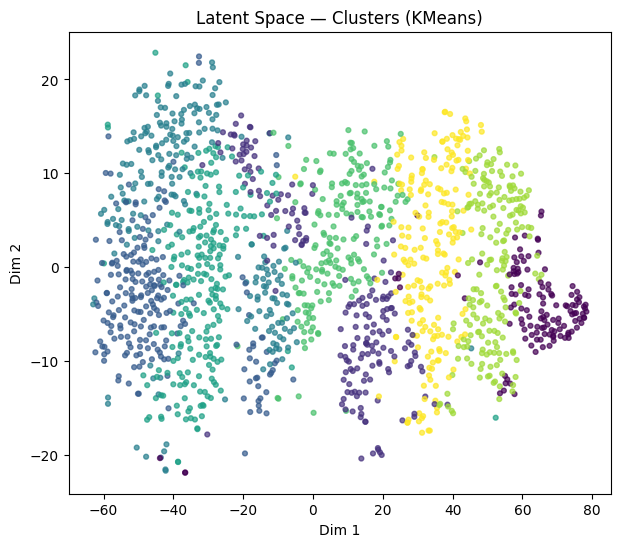

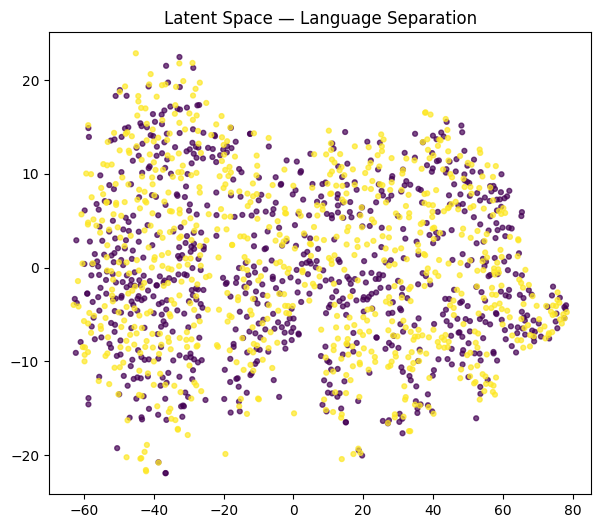

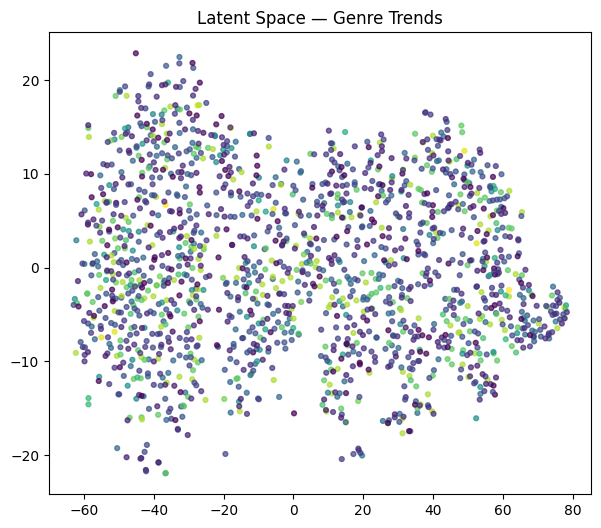


=== Language per Cluster ===
language  bangla  english
cluster                  
0          0.484    0.516
1          0.457    0.543
2          0.559    0.441
3          0.468    0.532
4          0.504    0.496
5          0.540    0.460
6          0.546    0.454
7          0.438    0.562

=== Genre per Cluster (Top) ===
genre    Metal  Uncategorized  country    pop    rap   rock  আধুনিক  \
cluster                                                               
0        0.070          0.000    0.047  0.156  0.164  0.078   0.117   
1        0.106          0.005    0.096  0.133  0.090  0.117   0.101   
2        0.070          0.000    0.075  0.075  0.089  0.131   0.150   
3        0.121          0.000    0.130  0.069  0.078  0.134   0.087   
4        0.112          0.008    0.108  0.083  0.088  0.104   0.142   
5        0.086          0.000    0.101  0.081  0.106  0.086   0.141   
6        0.082          0.000    0.103  0.088  0.057  0.124   0.124   
7        0.101          0.005    0.087

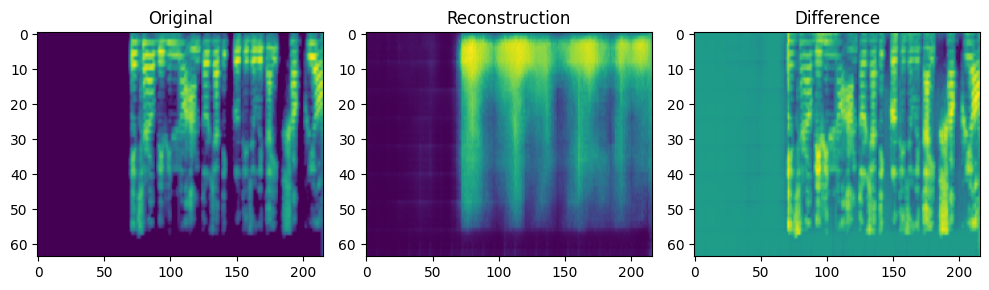

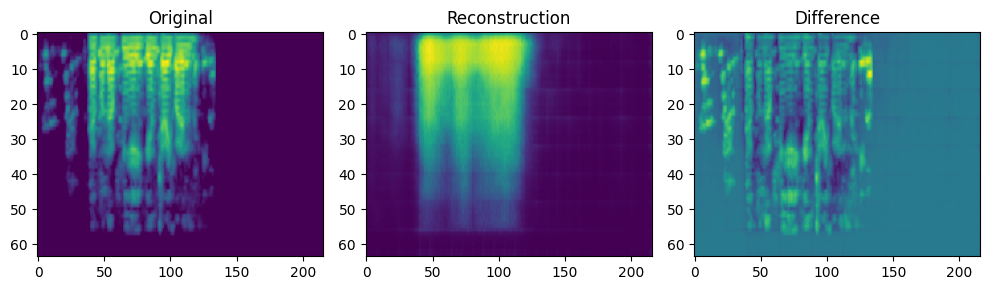

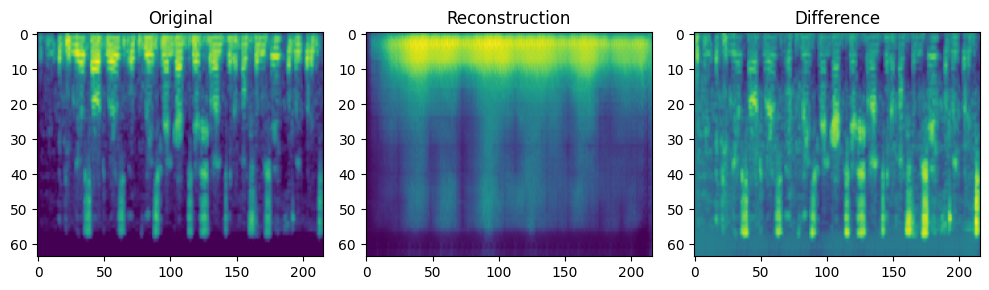


Visualization complete ✔


In [82]:
# ================= VISUALIZATION BLOCK =================

import numpy as np
import pandas as pd
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

model.eval()

# ---------- 1️⃣ t-SNE on latent space ----------
tsne = TSNE(n_components=2, perplexity=35, learning_rate=200, random_state=42)
Z2 = tsne.fit_transform(Z)
print("t-SNE:", Z2.shape)

# --- clusters ---
plt.figure(figsize=(7,6))
plt.scatter(Z2[:,0], Z2[:,1], c=km_labels, s=12, alpha=0.7)
plt.title("Latent Space — Clusters (KMeans)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.show()

# --- language ---
lang_colors = df_all["language"].map({"bangla":0,"english":1}).values
plt.figure(figsize=(7,6))
plt.scatter(Z2[:,0], Z2[:,1], c=lang_colors, s=12, alpha=0.7)
plt.title("Latent Space — Language Separation")
plt.show()

# --- genre ---
gids = LabelEncoder().fit_transform(df_all["genre"])
plt.figure(figsize=(7,6))
plt.scatter(Z2[:,0], Z2[:,1], c=gids, s=12, alpha=0.7)
plt.title("Latent Space — Genre Trends")
plt.show()


# ---------- 2️⃣ Cluster distributions ----------
df_vis = pd.DataFrame({
    "cluster": km_labels,
    "genre": df_all["genre"],
    "language": df_all["language"]
})

print("\n=== Language per Cluster ===")
print(pd.crosstab(df_vis["cluster"], df_vis["language"], normalize="index").round(3))

print("\n=== Genre per Cluster (Top) ===")
print(pd.crosstab(df_vis["cluster"], df_vis["genre"], normalize="index").round(3))


# ---------- 3️⃣ Reconstruction examples ----------
xa, xl = next(iter(train_loader))
xa, xl = xa.to(device), xl.to(device)

with torch.no_grad():
    recon, _, _, _ = model(xa, xl)

xa = xa.cpu().numpy()
recon = recon.cpu().numpy()

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(xa[i,0], aspect='auto')
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(recon[i,0], aspect='auto')
    plt.title("Reconstruction")

    plt.subplot(1,3,3)
    plt.imshow(xa[i,0]-recon[i,0], aspect='auto')
    plt.title("Difference")

    plt.tight_layout()
    plt.show()

print("\nVisualization complete ✔")


In [84]:
# ==============================================================
#     CLUSTERING COMPARISON:  VAE vs PCA vs AUTOENCODER
# ==============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score
)

device = "cuda" if torch.cuda.is_available() else "cpu"


# --------------------------------------------------------------
# Helper: safe evaluation
# --------------------------------------------------------------
def evaluate(name, labels, X, true=None):
    uniq = len(set(labels))
    if uniq <= 1:
        print(f"{name:18} | Sil=NA   | DBI=NA   | ARI=NA   (only 1 cluster)")
        return

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    ari = adjusted_rand_score(true, labels) if true is not None else None

    print(f"{name:18} | Sil={sil:.3f} | DBI={dbi:.3f} | ARI={ari}")


# ==============================================================
# 1️⃣  VAE  +  KMeans   (latent Z already computed)
# ==============================================================
print("\n=== VAE + KMeans ===")
km_vae = KMeans(n_clusters=8, random_state=42).fit(Z)

evaluate(
    "VAE-KMeans",
    km_vae.labels_,
    Z,
    df_all["genre"] if "genre" in df_all else None
)


# ==============================================================
# 2️⃣  PCA  +  KMeans
# ==============================================================

print("\n=== PCA + KMeans ===")
pca = PCA(n_components=32, random_state=42)
Zp = pca.fit_transform(Xa)

km_pca = KMeans(n_clusters=8, random_state=42).fit(Zp)

evaluate(
    "PCA-KMeans",
    km_pca.labels_,
    Zp,
    df_all["genre"] if "genre" in df_all else None
)


# ==============================================================
# 3️⃣  AUTOENCODER + KMeans   (FIXED)
# ==============================================================

print("\n=== Autoencoder + KMeans (FIXED) ===")

class AE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 64)     # latent
        )

        self.dec = nn.Sequential(
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        z = self.enc(x)
        xhat = self.dec(z)
        return xhat, z


input_dim = Xa.shape[1]
ae = AE(input_dim).to(device)
opt = optim.Adam(ae.parameters(), lr=1e-3)

Xa_t = torch.tensor(Xa, dtype=torch.float32).to(device)

# ---- quick training ----
for _ in range(12):
    opt.zero_grad()
    recon, z = ae(Xa_t)
    loss = ((recon - Xa_t)**2).mean()
    loss.backward()
    opt.step()

# ---- latent embeddings ----
with torch.no_grad():
    _, Zae = ae(Xa_t)

Zae = Zae.cpu().numpy()

km_ae = KMeans(n_clusters=8, random_state=42).fit(Zae)

evaluate(
    "AE-KMeans",
    km_ae.labels_,
    Zae,
    df_all["genre"] if "genre" in df_all else None
)



=== VAE + KMeans ===
VAE-KMeans         | Sil=0.099 | DBI=2.385 | ARI=-0.00040445210992400097

=== PCA + KMeans ===


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


PCA-KMeans         | Sil=0.129 | DBI=2.089 | ARI=-0.0006620913072630183

=== Autoencoder + KMeans (FIXED) ===
AE-KMeans          | Sil=0.378 | DBI=0.813 | ARI=-0.0017016196344211872


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
